In [1]:
import importlib
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from utils.utils import load_json_file
import utils.comparison_utils.bad_cases as cmp_bad_cases
import utils.comparison_utils as cmp
import utils.visualization as viz

# Reload explícito para evitar cache de módulo no notebook após refactors.
cmp_bad_cases = importlib.reload(cmp_bad_cases)
cmp = importlib.reload(cmp)

# Fallback defensivo se a sessão ainda estiver com namespace antigo.
if not hasattr(cmp, "save_bad_cases_artifacts"):
    cmp.save_bad_cases_artifacts = cmp_bad_cases.save_bad_cases_artifacts
if not hasattr(cmp, "build_bad_cases_export_df"):
    cmp.build_bad_cases_export_df = cmp_bad_cases.build_bad_cases_export_df

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
        "savefig.dpi": 300,
    },
)
plt.close("all")

SPLIT_PATHS_BY_RESOLUTION = {
    "mid_res": {
        "train": "../output/segmentation/8.final_results/mid_res/2026-03-05_15-35-52",
        "val": "../output/segmentation/8.final_results/mid_res/2026-03-27_08-43-09",
        "test": "../output/segmentation/8.final_results/mid_res/2026-03-30_20-48-16",
    },
    "high_res": {
        "train": "../output/segmentation/8.final_results/high_res/2026-03-23_14-24-53",
        "val": "../output/segmentation/8.final_results/high_res/2026-03-20_20-41-26",
        "test": "../output/segmentation/8.final_results/high_res/2026-04-04_10-01-42",
    },
}

VALID_SPLITS = ("train", "val", "test")
SUCCESS_STATUS = ["ambos toleráveis", "ambos corretos"]

# Resultados Testes

## Carregamento de dados

Nesta seção ficam todas as células de carregamento dos datasets de validação e dos casos ruins.

### Dados para comparação com métodos de IA

In [2]:

IA_RESULTS_BASE = Path("../output/ia_results")
MATH_TEST_SUMMARY_PATHS = {
    resolution: {
        split_name: Path(split_path) / f"ostios_{split_name}_summary.csv"
        for split_name, split_path in split_paths.items()
        if split_name in VALID_SPLITS
    }
    for resolution, split_paths in SPLIT_PATHS_BY_RESOLUTION.items()
}

ia_results_df, missing_ia_files = cmp.load_ia_results_for_comparison(IA_RESULTS_BASE)
math_results_df, missing_math_files = cmp.load_math_results_for_comparison(MATH_TEST_SUMMARY_PATHS)
comparison_raw_df = pd.concat([ia_results_df, math_results_df], ignore_index=True)
comparison_agg_df = cmp.build_comparison_agg_df(comparison_raw_df)

print("Shapes carregados para comparação IA:")
print("- IA:", ia_results_df.shape)
print("- Matemático:", math_results_df.shape)
print("- Consolidado:", comparison_raw_df.shape)
print("- Agregado:", comparison_agg_df.shape)

if missing_ia_files:
    print("\nAvisos IA:")
    for msg in missing_ia_files:
        print("-", msg)

if missing_math_files:
    print("\nAvisos Matemático:")
    for msg in missing_math_files:
        print("-", msg)

Shapes carregados para comparação IA:
- IA: (1400, 7)
- Matemático: (1541, 7)
- Consolidado: (2941, 7)
- Agregado: (9, 12)


### Dados de validação (30, 60 e 90 imagens)

In [3]:
path_60_val_tests = "../output/segmentation/5.val_diff/2026-03-08_15-43-56"
path_90_val_tests = "../output/segmentation/5.val_diff/2026-03-08_18-48-56"
path_30_val_tests = "../output/segmentation/8.final_results/mid_res/2026-03-27_08-43-09"

json_file_name = "ostios_val_metadata.json"
csv_file_name = "ostios_val_summary.csv"

paths_val_tests = [path_30_val_tests, path_60_val_tests, path_90_val_tests]
num_tests = [30, 60, 90]

dict_val_tests = {}

for path, num in zip(paths_val_tests, num_tests):
    json_path = os.path.join(path, json_file_name)
    csv_path = os.path.join(path, csv_file_name)

    json_data = load_json_file(json_path)
    csv_data = pd.read_csv(csv_path)

    dict_val_tests[num] = {
        "json": json_data,
        "csv": csv_data,
    }

    success_percent = cmp.get_total_success_percent(json_data)
    dice_mean = json_data.get("results_summary", {}).get("dice_artery_mean", np.nan)

    print("Percentual de óstios detectados para {} imagens: {}".format(num, success_percent))
    print("Dice médio para {} imagens: {}".format(num, dice_mean))
    print()

Percentual de óstios detectados para 30 imagens: 93.33333333333333
Dice médio para 30 imagens: 0.6510994123228695

Percentual de óstios detectados para 60 imagens: 85.0
Dice médio para 60 imagens: 0.634258141192984

Percentual de óstios detectados para 90 imagens: 86.66666666666667
Dice médio para 90 imagens: 0.6347419572961731



### Dados dos casos ruins (bad_tests)

In [4]:
bad_cases_split = "test"  # options: "train", "val" or "test"
BAD_CASES_EXPORT_DIR = "../output/segmentation/8.final_results/bad_cases_exports"

if bad_cases_split not in VALID_SPLITS:
    raise ValueError("bad_cases_split must be 'train', 'val' or 'test'.")

if bad_cases_split not in SPLIT_PATHS_BY_RESOLUTION["mid_res"]:
    raise ValueError(f"Split '{bad_cases_split}' is not available for mid_res.")
if bad_cases_split not in SPLIT_PATHS_BY_RESOLUTION["high_res"]:
    print(f"Warning: split '{bad_cases_split}' is not available for high_res. Only mid_res will be shown.")

df_mid_res = cmp.load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "mid_res", bad_cases_split)
df_mid_bad_res = cmp.get_bad_cases(df_mid_res)
mid_export = cmp.save_bad_cases_artifacts(
    df_bad_cases=df_mid_bad_res,
    output_dir=BAD_CASES_EXPORT_DIR,
    subset_name=bad_cases_split,
    resolution="mid_res",
)

mid_total_cases = int(df_mid_res.shape[0])
mid_bad_cases = int(df_mid_bad_res.shape[0])
mid_bad_percent = (100 * mid_bad_cases / mid_total_cases) if mid_total_cases > 0 else 0.0

bad_summary_rows = [
    {
        "resolution": "mid_res",
        "subset": bad_cases_split,
        "total_cases": mid_total_cases,
        "bad_cases": mid_bad_cases,
        "bad_cases_percent": mid_bad_percent,
        "csv_path": mid_export["csv_path"],
        "json_path": mid_export["json_path"],
    }
]

df_high_res = cmp.load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "high_res", bad_cases_split)
if df_high_res is not None:
    df_high_bad_res = cmp.get_bad_cases(df_high_res)
    high_export = cmp.save_bad_cases_artifacts(
        df_bad_cases=df_high_bad_res,
        output_dir=BAD_CASES_EXPORT_DIR,
        subset_name=bad_cases_split,
        resolution="high_res",
    )

    high_total_cases = int(df_high_res.shape[0])
    high_bad_cases = int(df_high_bad_res.shape[0])
    high_bad_percent = (100 * high_bad_cases / high_total_cases) if high_total_cases > 0 else 0.0

    bad_summary_rows.append(
        {
            "resolution": "high_res",
            "subset": bad_cases_split,
            "total_cases": high_total_cases,
            "bad_cases": high_bad_cases,
            "bad_cases_percent": high_bad_percent,
            "csv_path": high_export["csv_path"],
            "json_path": high_export["json_path"],
        }
    )
else:
    df_high_res = pd.DataFrame(columns=df_mid_res.columns)
    df_high_bad_res = pd.DataFrame(columns=df_mid_bad_res.columns)

bad_summary_df = pd.DataFrame(bad_summary_rows)

display(bad_summary_df)
print("Selected bad cases subset:", bad_cases_split)
print("Mid Res Shape:", df_mid_res.shape)
print("Mid Res Bad Results Shape:", df_mid_bad_res.shape)
print("Mid Res exports:", mid_export["csv_path"], "|", mid_export["json_path"])
if not df_high_res.empty:
    print("High Res Shape:", df_high_res.shape)
    print("High Res Bad Results Shape:", df_high_bad_res.shape)
    print("High Res exports:", high_export["csv_path"], "|", high_export["json_path"])


,resolution,subset,total_cases,bad_cases,bad_cases_percent,csv_path,json_path
0,mid_res,test,700,137,19.571429,../output/segmentation/8.final_results/bad_cas...,../output/segmentation/8.final_results/bad_cas...
1,high_res,test,700,227,32.428571,../output/segmentation/8.final_results/bad_cas...,../output/segmentation/8.final_results/bad_cas...


Selected bad cases subset: test
Mid Res Shape: (700, 17)
Mid Res Bad Results Shape: (137, 18)
Mid Res exports: ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_test_mid_res.csv | ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_test_mid_res.json
High Res Shape: (700, 17)
High Res Bad Results Shape: (227, 18)
High Res exports: ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_test_high_res.csv | ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_test_high_res.json


### Dados de train, test e validação

In [5]:
subset_rows = []
for resolution, split_paths in SPLIT_PATHS_BY_RESOLUTION.items():
    for subset_name in VALID_SPLITS:
        metadata = cmp.load_split_metadata(SPLIT_PATHS_BY_RESOLUTION, resolution, subset_name)
        summary_df = cmp.load_split_summary(SPLIT_PATHS_BY_RESOLUTION, resolution, subset_name)

        if metadata is None or summary_df is None:
            subset_rows.append(
                {
                    "subset": subset_name,
                    "resolution": resolution,
                    "num_images": np.nan,
                    "mean_dice": np.nan,
                    "mean_dice_correct": np.nan,
                    "mean_dice_all": np.nan,
                    "execution_time_min": np.nan,
                    "total_success_percent": np.nan,
                    "total_ostia_success": np.nan,
                    "is_available": False,
                }
            )
            continue

        execution_time_seconds = cmp.get_execution_time_seconds(metadata)
        num_images = cmp.get_num_images(metadata)
        total_success_percent = cmp.get_total_success_percent(metadata)

        dice_all = pd.to_numeric(summary_df["dice_artery"], errors="coerce")
        dice_all = dice_all.dropna()
        mean_dice_all = dice_all.mean() if not dice_all.empty else np.nan

        if {"both_correct", "both_tolerable"}.issubset(summary_df.columns):
            correct_mask = (
                summary_df["both_correct"].fillna(False).astype(bool)
                | summary_df["both_tolerable"].fillna(False).astype(bool)
            )
        elif "ostia_status" in summary_df.columns:
            correct_mask = summary_df["ostia_status"].isin(["both_correct", "both_tolerable"])
        else:
            status_series = summary_df.get("status", pd.Series(index=summary_df.index))
            correct_mask = status_series.isin(["ambos corretos", "ambos toleráveis"])

        dice_correct = pd.to_numeric(
            summary_df.loc[correct_mask, "dice_artery"],
            errors="coerce",
        ).dropna()
        mean_dice_correct = dice_correct.mean() if not dice_correct.empty else np.nan

        if pd.notna(num_images) and pd.notna(total_success_percent):
            total_ostia_success = (num_images * 2) * (total_success_percent / 100)
        else:
            total_ostia_success = np.nan

        subset_rows.append(
            {
                "subset": subset_name,
                "resolution": resolution,
                "num_images": num_images,
                "mean_dice": mean_dice_correct,
                "mean_dice_correct": mean_dice_correct,
                "mean_dice_all": mean_dice_all,
                "execution_time_min": execution_time_seconds / 60 if pd.notna(execution_time_seconds) else np.nan,
                "total_success_percent": total_success_percent,
                "total_ostia_success": total_ostia_success,
                "is_available": True,
            }
        )

subset_summary_df = pd.DataFrame(subset_rows)
subset_summary_df["subset"] = pd.Categorical(subset_summary_df["subset"], categories=list(VALID_SPLITS), ordered=True)
subset_summary_df = subset_summary_df.sort_values(["subset", "resolution"])

# Backward-compatible aliases for existing plotting helpers.
subset_summary_df["resolucao"] = subset_summary_df["resolution"]
subset_summary_df["num_imagens"] = subset_summary_df["num_images"]
subset_summary_df["dice_medio"] = subset_summary_df["mean_dice"]
subset_summary_df["dice_medio_correto"] = subset_summary_df["mean_dice_correct"]
subset_summary_df["dice_medio_todos"] = subset_summary_df["mean_dice_all"]
subset_summary_df["tempo_execucao_min"] = subset_summary_df["execution_time_min"]
subset_summary_df["sucesso_total_percent"] = subset_summary_df["total_success_percent"]
subset_summary_df["ostios_sucesso_total"] = subset_summary_df["total_ostia_success"]
subset_summary_df["disponivel"] = subset_summary_df["is_available"]

display(subset_summary_df)

missing_rows = subset_summary_df[~subset_summary_df["is_available"]]
if not missing_rows.empty:
    print("Combinations without data:")
    display(missing_rows[["subset", "resolution"]])


,subset,resolution,num_images,mean_dice,mean_dice_correct,mean_dice_all,execution_time_min,total_success_percent,total_ostia_success,is_available,resolucao,num_imagens,dice_medio,dice_medio_correto,dice_medio_todos,tempo_execucao_min,sucesso_total_percent,ostios_sucesso_total,disponivel
3,train,high_res,270,0.566495,0.566495,0.566495,1903.192395,65.925926,356.0,True,high_res,270,0.566495,0.566495,0.566495,1903.192395,65.925926,356.0,True
0,train,mid_res,270,0.614006,0.614006,0.614006,369.559395,88.148148,476.0,True,mid_res,270,0.614006,0.614006,0.614006,369.559395,88.148148,476.0,True
4,val,high_res,30,0.571140,0.571140,0.571140,236.837366,86.666667,52.0,True,high_res,30,0.571140,0.571140,0.571140,236.837366,86.666667,52.0,True
1,val,mid_res,30,0.651099,0.651099,0.651099,49.648786,93.333333,56.0,True,mid_res,30,0.651099,0.651099,0.651099,49.648786,93.333333,56.0,True
5,test,high_res,700,0.550288,0.550288,0.550288,5070.273159,71.428571,1000.0,True,high_res,700,0.550288,0.550288,0.550288,5070.273159,71.428571,1000.0,True
2,test,mid_res,700,0.607369,0.607369,0.607369,1014.096081,84.285714,1180.0,True,mid_res,700,0.607369,0.607369,0.607369,1014.096081,84.285714,1180.0,True


### Dados dos métodos de downscale

In [6]:
downscale_base_path = "../output/segmentation/1.downscale_method"
downscale_folders = sorted(
    [
        folder
        for folder in os.listdir(downscale_base_path)
        if os.path.isdir(os.path.join(downscale_base_path, folder))
    ]
)

downscale_rows = []
for folder in downscale_folders:
    metadata_path = os.path.join(downscale_base_path, folder, "ostios_val_metadata.json")
    if not os.path.exists(metadata_path):
        continue

    metadata = load_json_file(metadata_path)

    preprocessing = metadata.get("preprocessing_config", {})
    results = metadata.get("results_summary", {})

    method = preprocessing.get("downscale_method", "unknown")
    interpolation = preprocessing.get("opencv_interpolation")

    if method == "scipy":
        method_label = "SciPy (NDI)"
    else:
        interp_label = str(interpolation).upper() if interpolation else "N/A"
        method_label = f"OpenCV ({interp_label})"

    success_total_percent = cmp.get_total_success_percent(metadata)
    execution_time_seconds = cmp.get_execution_time_seconds(metadata)

    downscale_rows.append(
        {
            "metodo": method_label,
            "tempo_execucao_min": execution_time_seconds / 60 if pd.notna(execution_time_seconds) else np.nan,
            "dice_medio": results.get("dice_artery_mean", np.nan),
            "sucesso_total_percent": success_total_percent,
        }
    )

downscale_df = pd.DataFrame(downscale_rows)

method_order = ["SciPy (NDI)", "OpenCV (AREA)", "OpenCV (LINEAR)", "OpenCV (CUBIC)"]
downscale_df["metodo"] = pd.Categorical(downscale_df["metodo"], categories=method_order, ordered=True)
downscale_df = downscale_df.sort_values("metodo")

display(downscale_df)

,metodo,tempo_execucao_min,dice_medio,sucesso_total_percent
0,SciPy (NDI),105.977441,0.636033,86.666667
1,OpenCV (AREA),102.172383,0.620805,86.666667
2,OpenCV (LINEAR),101.717742,0.620805,86.666667
3,OpenCV (CUBIC),103.846065,0.622995,83.333333


## Resultados dos métodos de downscale

### Tempo de execução por método

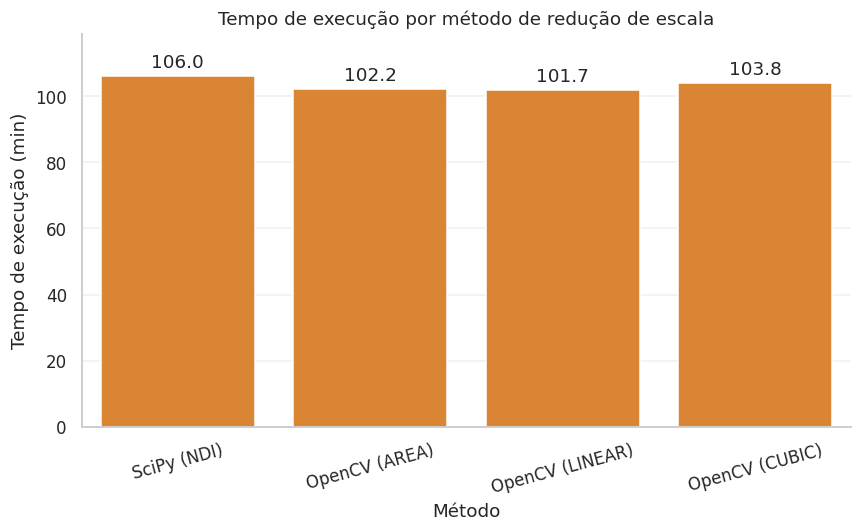

In [7]:
ax_down_time = viz.category.plot_downscale_execution_time(
    downscale_df=downscale_df,
    color="#F58518",
)

### Dice médio por método

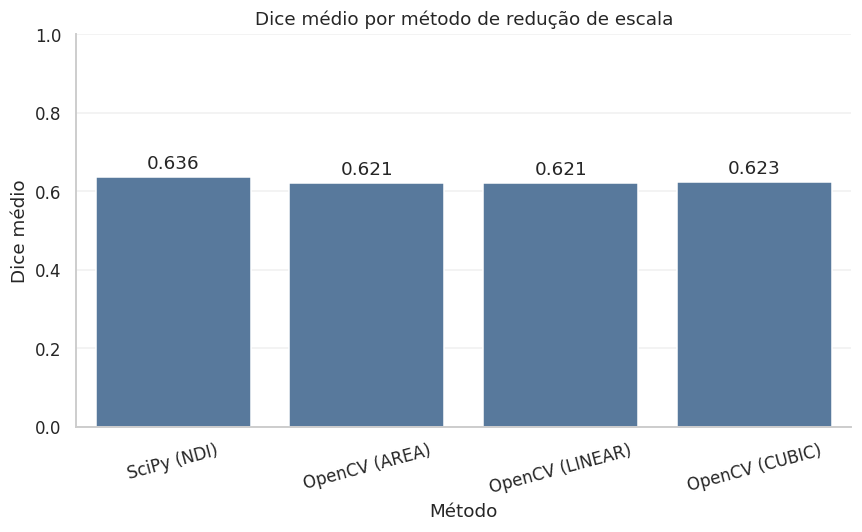

In [8]:
ax_down_dice = viz.category.plot_downscale_dice(
    downscale_df=downscale_df,
    color="#4C78A8",
)

### Sucesso na detecção dos óstios por método

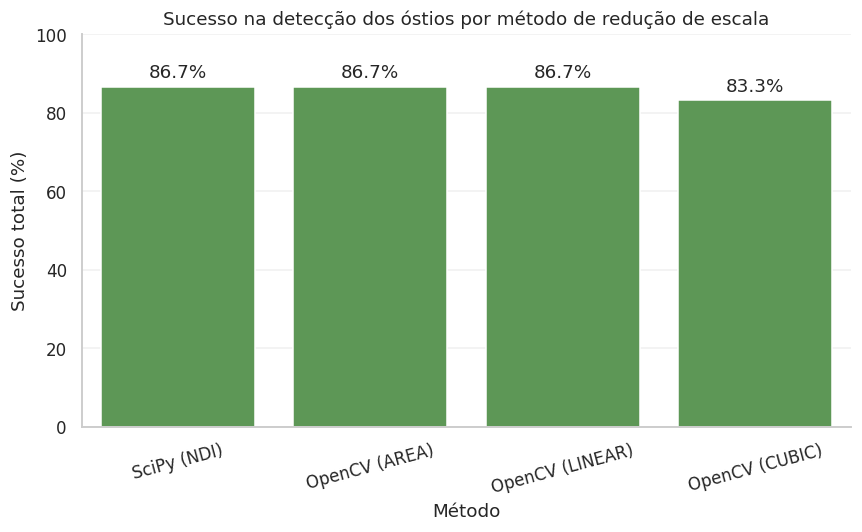

In [9]:
ax_down_success = viz.category.plot_downscale_ostia_success(
    downscale_df=downscale_df,
    color="#54A24B",
)

## Resultados por quantidade de dados de validação

### Dice médio

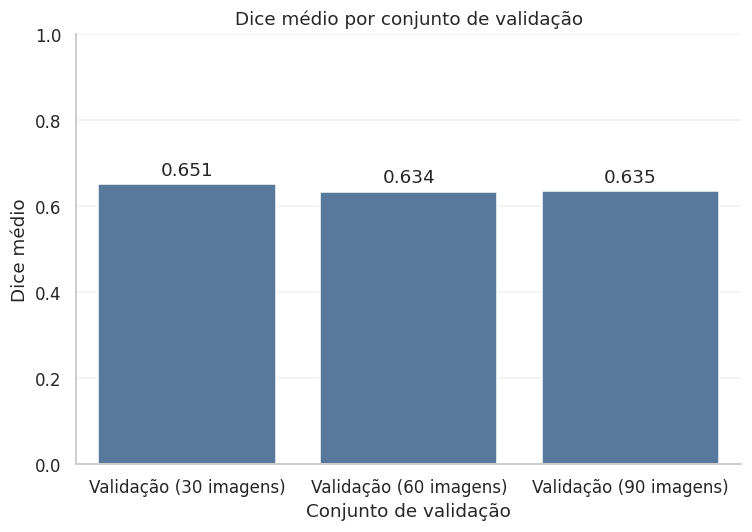

In [10]:
summary_rows = []

for num in num_tests:
    csv_df = dict_val_tests[num]["csv"].copy()
    json_df = dict_val_tests[num]["json"].copy()

    dice_scores = pd.to_numeric(csv_df["dice_artery"], errors="coerce").dropna()
    execution_time_seconds = cmp.get_execution_time_seconds(json_df)
    total_success_percent = cmp.get_total_success_percent(json_df)

    summary_rows.append(
        {
            "dataset": f"Validação ({num} imagens)",
            "dice_medio": dice_scores.mean(),
            "tempo_execucao_s": execution_time_seconds,
            "tempo_execucao_min": execution_time_seconds / 60 if pd.notna(execution_time_seconds) else np.nan,
            "sucesso_total_percent": total_success_percent,
        }
    )

summary_df = pd.DataFrame(summary_rows)

ax1 = viz.category.plot_validation_dice(
    summary_df=summary_df,
    color="#4C78A8",
)

### Tempo de execução

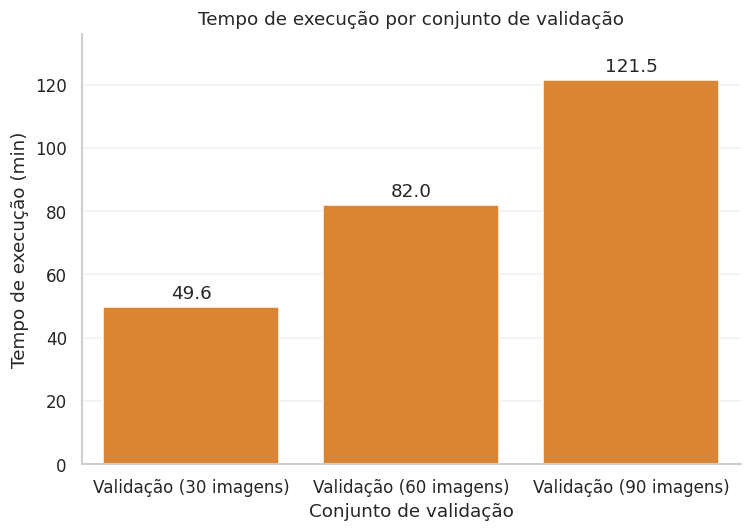

In [11]:
ax2 = viz.category.plot_validation_execution_time(
    summary_df=summary_df,
    color="#F58518",
)

### Sucesso total de detecção de óstios

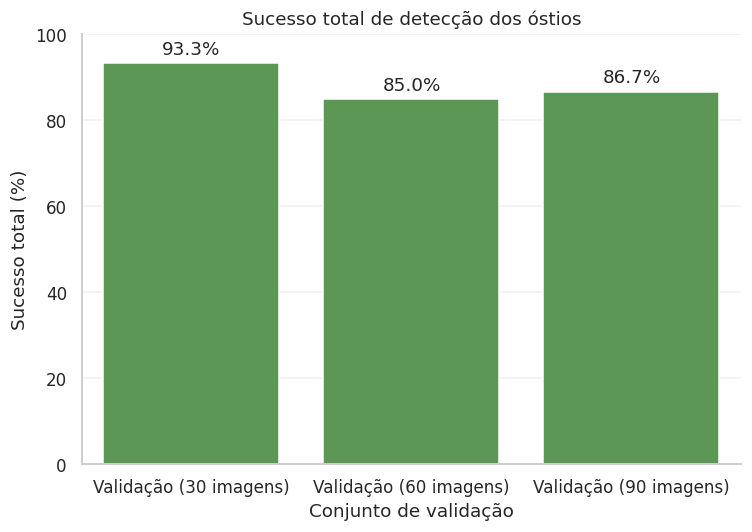

In [12]:
ax3 = viz.category.plot_validation_ostia_success(
    summary_df=summary_df,
    color="#54A24B",
)

## Resultados por subset: val, train e test

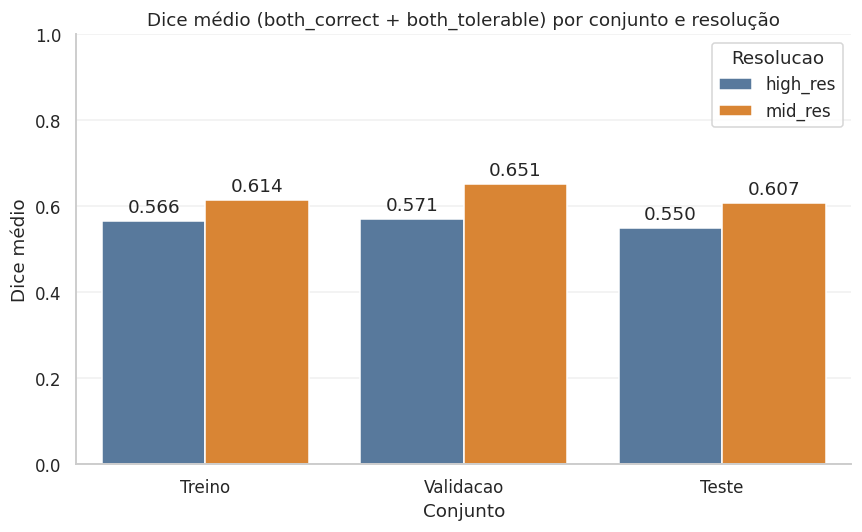

In [13]:
ax_subset = viz.subset.plot_subset_metric_by_resolution(
    subset_summary_df=subset_summary_df,
    metric_col="dice_medio_correto",
    title="Dice médio (both_correct + both_tolerable) por conjunto e resolução",
    ylabel="Dice médio",
    palette=["#4C78A8", "#F58518"],
    ylim=(0, 1),
    bar_label_fmt="%.3f",
)

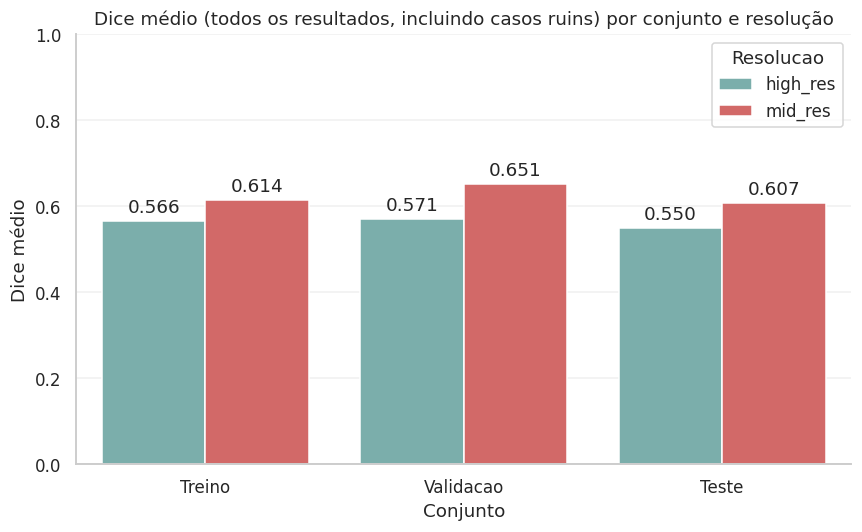

In [14]:
ax_subset_all = viz.subset.plot_subset_metric_by_resolution(
    subset_summary_df=subset_summary_df,
    metric_col="dice_medio_todos",
    title="Dice médio (todos os resultados, incluindo casos ruins) por conjunto e resolução",
    ylabel="Dice médio",
    palette=["#72B7B2", "#E45756"],
    ylim=(0, 1),
    bar_label_fmt="%.3f",
)

### Impacto dos casos ruins no Dice

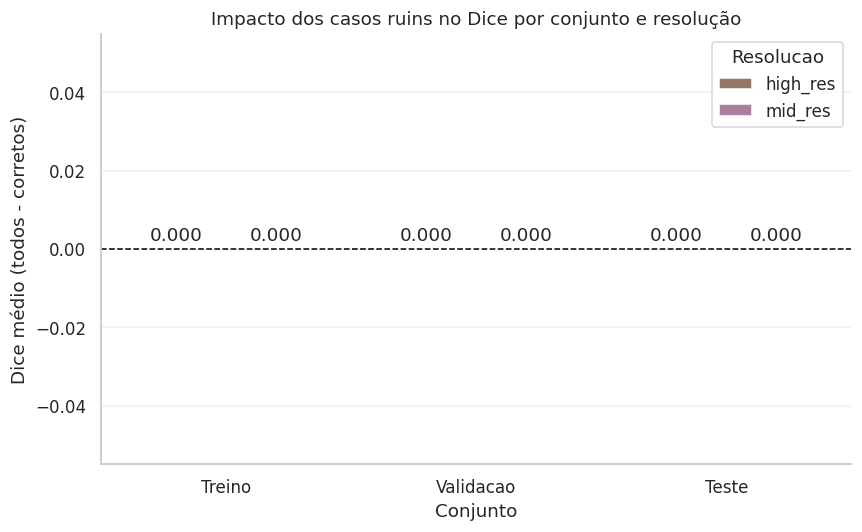

In [15]:
subset_summary_df["delta_dice"] = (
    subset_summary_df["dice_medio_todos"] - subset_summary_df["dice_medio_correto"]
)

ax_subset_delta = viz.subset.plot_subset_metric_by_resolution(
    subset_summary_df=subset_summary_df,
    metric_col="delta_dice",
    title="Impacto dos casos ruins no Dice por conjunto e resolução",
    ylabel="Dice médio (todos - corretos)",
    palette=["#9C755F", "#B279A2"],
    hline_y=0,
    bar_label_fmt="%.3f",
)

### Tempo de execução por conjunto

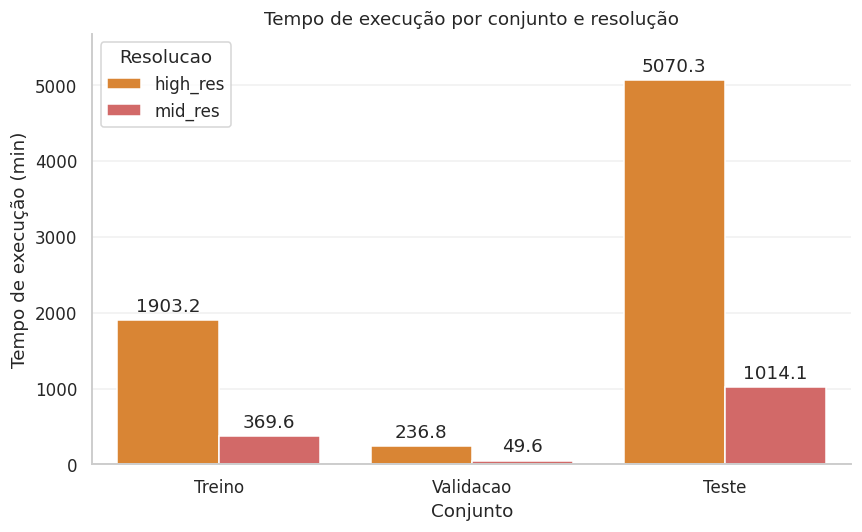

In [16]:
ax_subset_time = viz.subset.plot_subset_execution_time_by_resolution(
    subset_summary_df=subset_summary_df,
    palette=["#F58518", "#E45756"],
)

### Percentual de óstios detectados com sucesso por conjunto

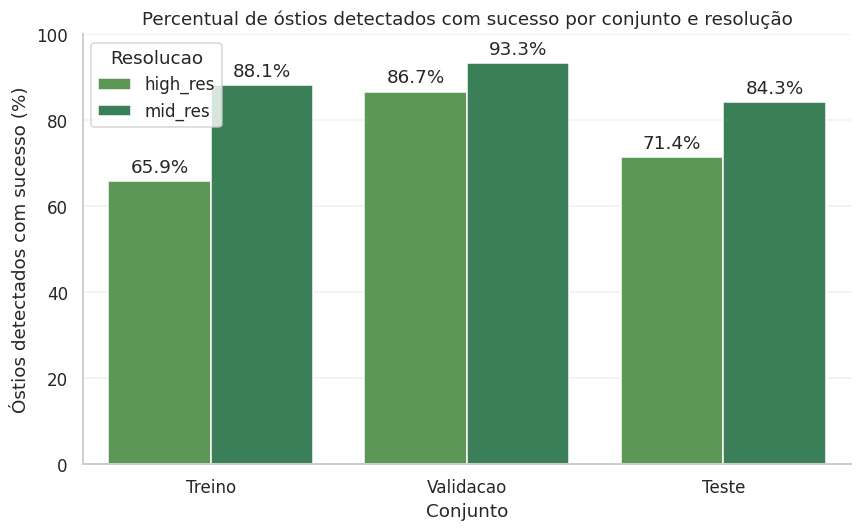

In [17]:
ax_subset_success = viz.subset.plot_subset_ostia_success_by_resolution(
    subset_summary_df=subset_summary_df,
    palette=["#54A24B", "#2E8B57"],
)

## Casos Ruins por Subset

### Validação (Val)

CASOS RUINS - VALIDAÇÃO (VAL)

Mid Res: 2/30 casos ruins (6.7%)
High Res: 5/30 casos ruins (16.7%)

Saved bad cases exports:
- val/mid_res: ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_val_mid_res.csv | ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_val_mid_res.json
- val/high_res: ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_val_high_res.csv | ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_val_high_res.json


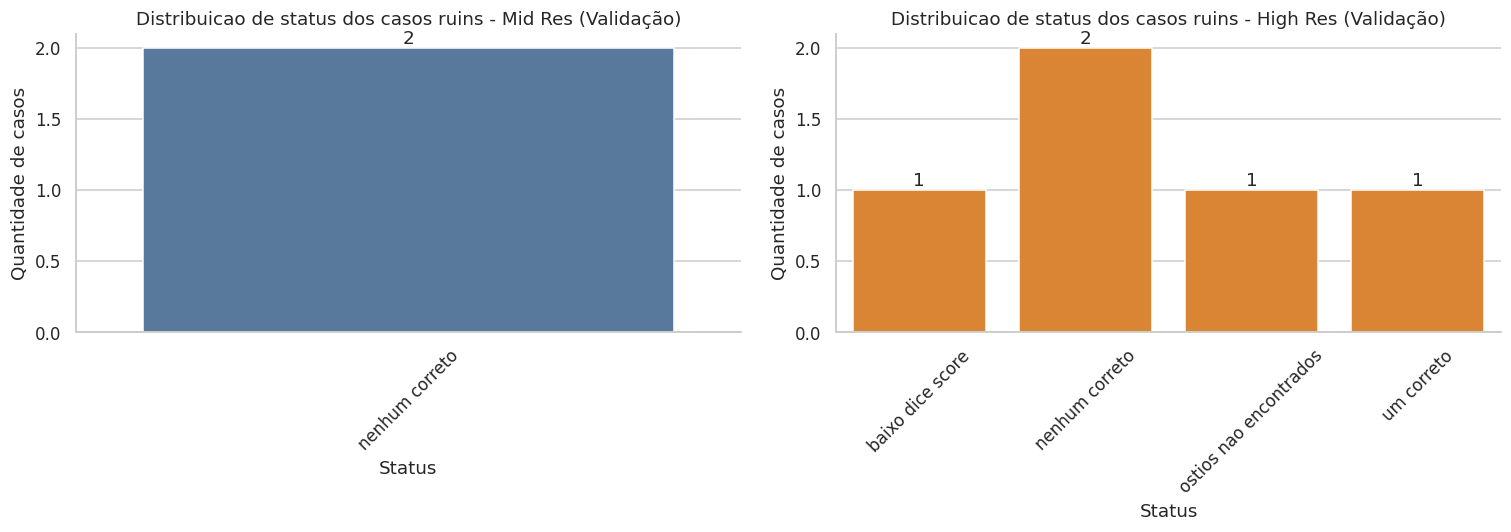


------------------------------------------------------------
COMPARATIVO MID vs HIGH - Validação
------------------------------------------------------------
Mesmo caso com Dice < 0.3 em ambos: 0
Ostios nao encontrados em ambos: 0
Um correto em ambos: 0
Nenhum correto em ambos: 1
Erro em ambos: 0
Exemplos (nenhum correto em ambos): [330]


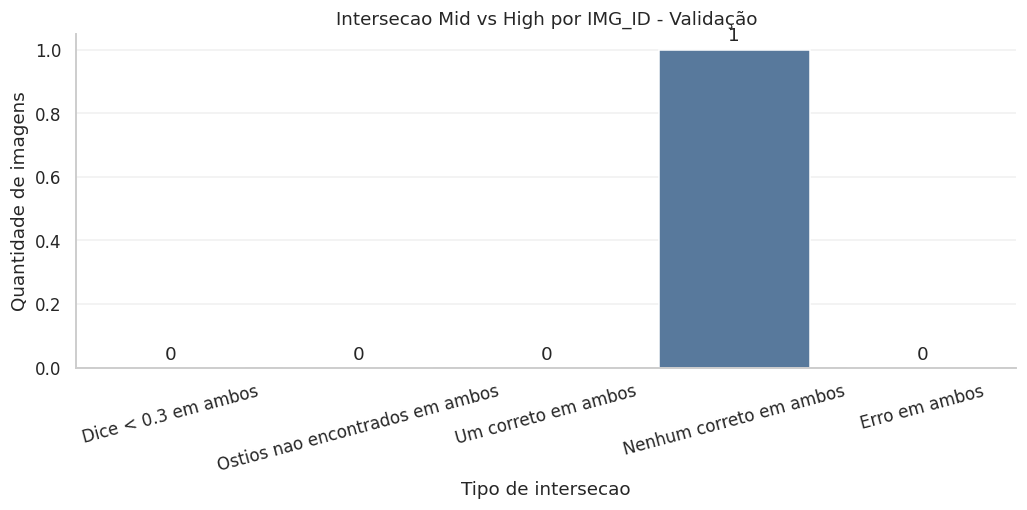

In [18]:
# Carregamento de dados de validação
df_mid_val = cmp.load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "mid_res", "val")
df_high_val = cmp.load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "high_res", "val")

df_mid_val_bad = cmp.get_bad_cases(df_mid_val) if df_mid_val is not None else pd.DataFrame()
df_high_val_bad = cmp.get_bad_cases(df_high_val) if df_high_val is not None else pd.DataFrame()

bad_cases_export_dir = globals().get(
    "BAD_CASES_EXPORT_DIR",
    "../output/segmentation/8.final_results/bad_cases_exports",
)

val_mid_export = cmp.save_bad_cases_artifacts(
    df_bad_cases=df_mid_val_bad,
    output_dir=bad_cases_export_dir,
    subset_name="val",
    resolution="mid_res",
)

val_high_export = None
if df_high_val is not None:
    val_high_export = cmp.save_bad_cases_artifacts(
        df_bad_cases=df_high_val_bad,
        output_dir=bad_cases_export_dir,
        subset_name="val",
        resolution="high_res",
    )

# Resumo de casos ruins para validação
print("="*60)
print("CASOS RUINS - VALIDAÇÃO (VAL)")
print("="*60)
print(f"\nMid Res: {len(df_mid_val_bad)}/{len(df_mid_val)} casos ruins ({100*len(df_mid_val_bad)/len(df_mid_val):.1f}%)" if df_mid_val is not None else "Mid Res: Sem dados")
if df_high_val is not None:
    print(f"High Res: {len(df_high_val_bad)}/{len(df_high_val)} casos ruins ({100*len(df_high_val_bad)/len(df_high_val):.1f}%)")
else:
    print("High Res: Sem dados disponíveis")

print("\nSaved bad cases exports:")
print("- val/mid_res:", val_mid_export["csv_path"], "|", val_mid_export["json_path"])
if val_high_export is not None:
    print("- val/high_res:", val_high_export["csv_path"], "|", val_high_export["json_path"])

# Plotar
viz.bad_cases.plot_bad_cases_by_subset(df_mid_val, df_high_val, df_mid_val_bad, df_high_val_bad, "Validação")

# Comparativo de interseção por IMG_ID entre resoluções
val_shared_bad = viz.bad_cases.compare_shared_bad_cases(df_mid_val, df_high_val, "Validação")

### Treino (Train)

CASOS RUINS - TREINO (TRAIN)

Mid Res: 60/270 casos ruins (22.2%)
High Res: 99/270 casos ruins (36.7%)

Saved bad cases exports:
- train/mid_res: ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_train_mid_res.csv | ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_train_mid_res.json
- train/high_res: ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_train_high_res.csv | ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_train_high_res.json


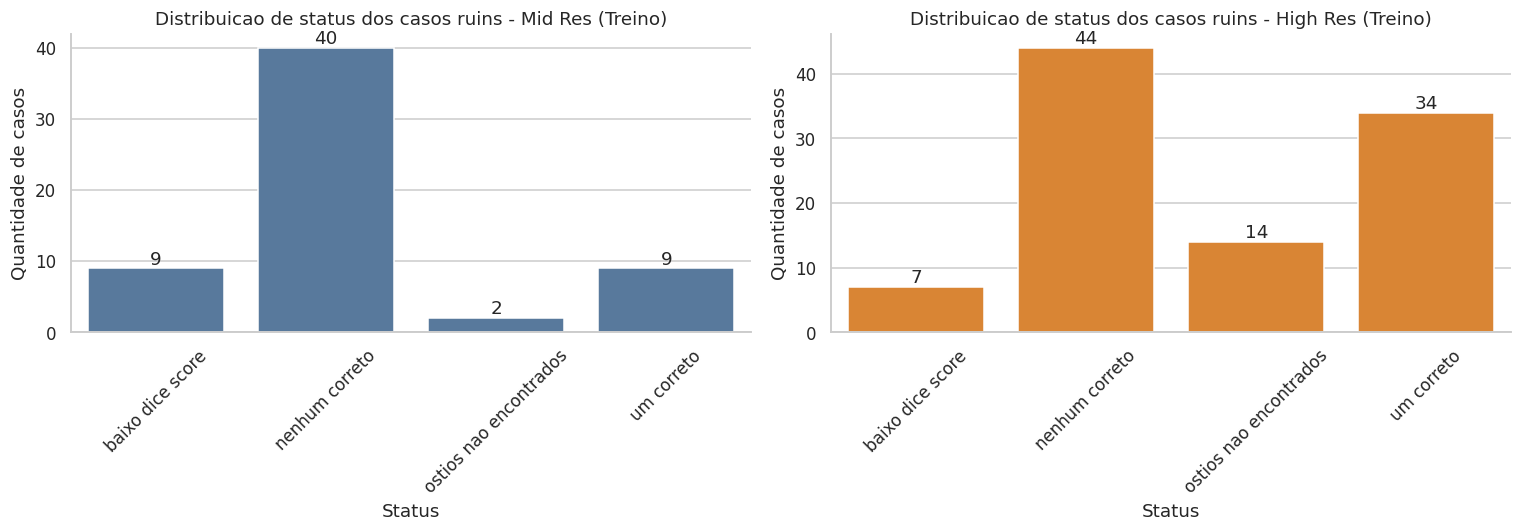


------------------------------------------------------------
COMPARATIVO MID vs HIGH - Treino
------------------------------------------------------------
Mesmo caso com Dice < 0.3 em ambos: 1
Ostios nao encontrados em ambos: 0
Um correto em ambos: 1
Nenhum correto em ambos: 14
Erro em ambos: 0
Exemplos (Dice baixo em ambos): [747]
Exemplos (um correto em ambos): [180]
Exemplos (nenhum correto em ambos): [23, 127, 190, 207, 316, 401, 515, 522, 702, 705]


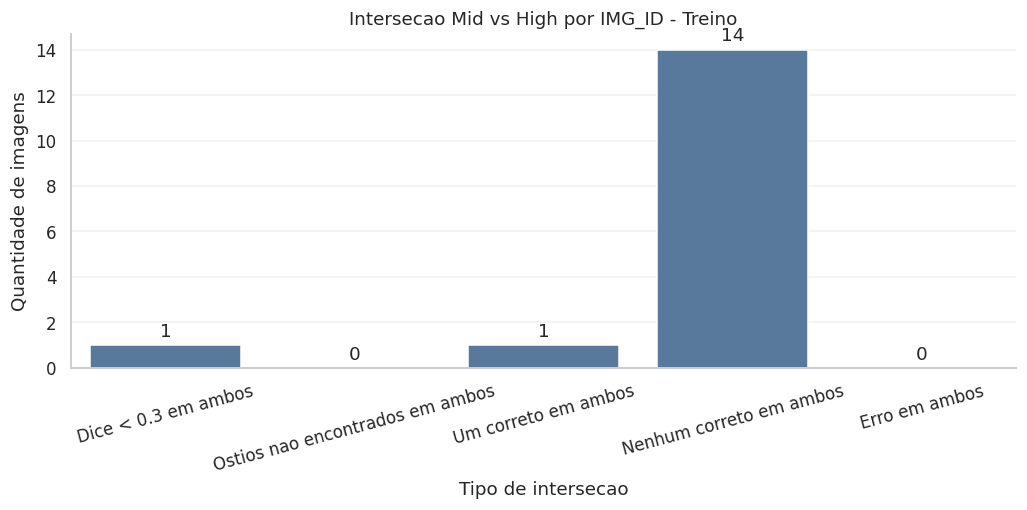

In [19]:
# Carregamento de dados de treino
df_mid_train = cmp.load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "mid_res", "train")
df_high_train = cmp.load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "high_res", "train")

df_mid_train_bad = cmp.get_bad_cases(df_mid_train) if df_mid_train is not None else pd.DataFrame()
df_high_train_bad = cmp.get_bad_cases(df_high_train) if df_high_train is not None else pd.DataFrame()

bad_cases_export_dir = globals().get(
    "BAD_CASES_EXPORT_DIR",
    "../output/segmentation/8.final_results/bad_cases_exports",
)

train_mid_export = cmp.save_bad_cases_artifacts(
    df_bad_cases=df_mid_train_bad,
    output_dir=bad_cases_export_dir,
    subset_name="train",
    resolution="mid_res",
)

train_high_export = None
if df_high_train is not None:
    train_high_export = cmp.save_bad_cases_artifacts(
        df_bad_cases=df_high_train_bad,
        output_dir=bad_cases_export_dir,
        subset_name="train",
        resolution="high_res",
    )

# Resumo de casos ruins para treino
print("="*60)
print("CASOS RUINS - TREINO (TRAIN)")
print("="*60)
print(f"\nMid Res: {len(df_mid_train_bad)}/{len(df_mid_train)} casos ruins ({100*len(df_mid_train_bad)/len(df_mid_train):.1f}%)" if df_mid_train is not None else "Mid Res: Sem dados")
if df_high_train is not None:
    print(f"High Res: {len(df_high_train_bad)}/{len(df_high_train)} casos ruins ({100*len(df_high_train_bad)/len(df_high_train):.1f}%)")
else:
    print("High Res: Sem dados disponíveis")

print("\nSaved bad cases exports:")
print("- train/mid_res:", train_mid_export["csv_path"], "|", train_mid_export["json_path"])
if train_high_export is not None:
    print("- train/high_res:", train_high_export["csv_path"], "|", train_high_export["json_path"])

# Plotar
viz.bad_cases.plot_bad_cases_by_subset(df_mid_train, df_high_train, df_mid_train_bad, df_high_train_bad, "Treino")

# Comparativo de interseção por IMG_ID entre resoluções
train_shared_bad = viz.bad_cases.compare_shared_bad_cases(df_mid_train, df_high_train, "Treino")

### Teste (Test)

CASOS RUINS - TESTE (TEST)

Mid Res: 137/700 casos ruins (19.6%)
High Res: 227/700 casos ruins (32.4%)

Saved bad cases exports:
- test/mid_res: ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_test_mid_res.csv | ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_test_mid_res.json
- test/high_res: ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_test_high_res.csv | ../output/segmentation/8.final_results/bad_cases_exports/bad_cases_test_high_res.json


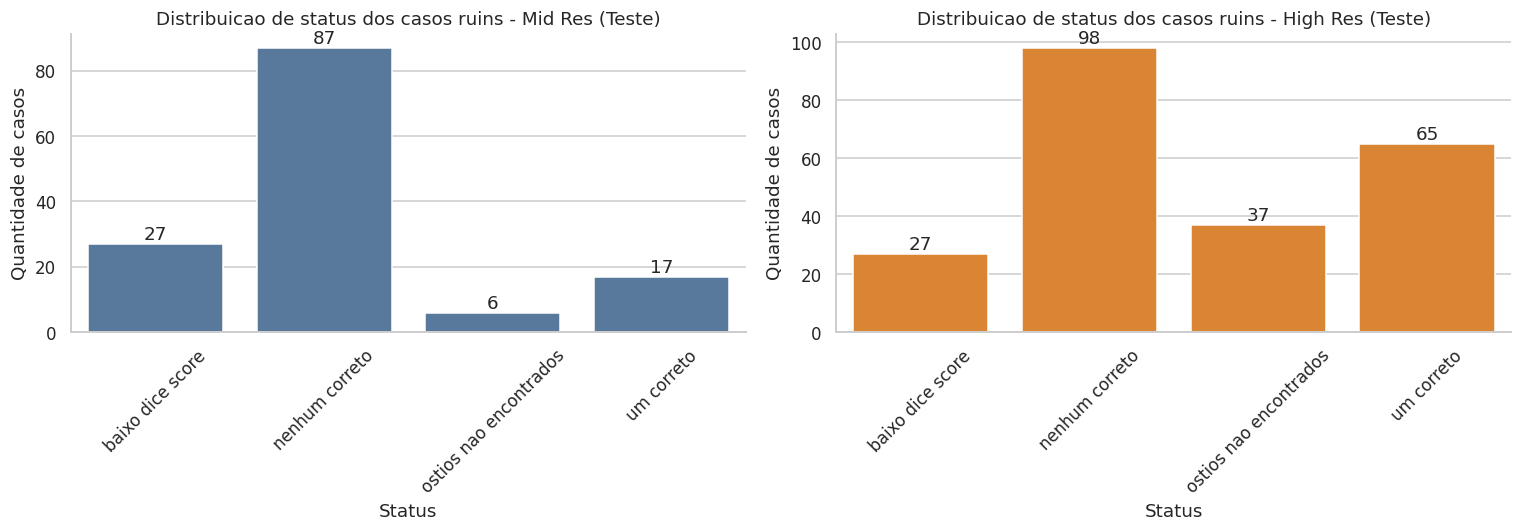


------------------------------------------------------------
COMPARATIVO MID vs HIGH - Teste
------------------------------------------------------------
Mesmo caso com Dice < 0.3 em ambos: 3
Ostios nao encontrados em ambos: 0
Um correto em ambos: 4
Nenhum correto em ambos: 31
Erro em ambos: 2
Exemplos (Dice baixo em ambos): [171, 595, 632]
Exemplos (um correto em ambos): [75, 272, 543, 561]
Exemplos (nenhum correto em ambos): [8, 66, 105, 133, 149, 182, 212, 218, 221, 297]
Exemplos (erro em ambos): [86, 657]


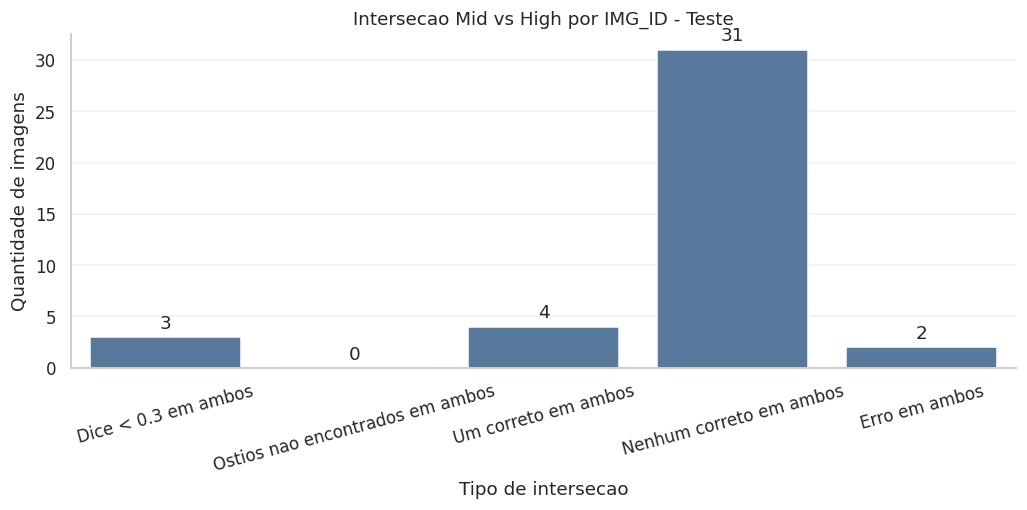

In [20]:
# Carregamento de dados de teste
df_mid_test = cmp.load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "mid_res", "test")
df_high_test = cmp.load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "high_res", "test")

df_mid_test_bad = cmp.get_bad_cases(df_mid_test) if df_mid_test is not None else pd.DataFrame()
df_high_test_bad = cmp.get_bad_cases(df_high_test) if df_high_test is not None else pd.DataFrame()

bad_cases_export_dir = globals().get(
    "BAD_CASES_EXPORT_DIR",
    "../output/segmentation/8.final_results/bad_cases_exports",
)

test_mid_export = cmp.save_bad_cases_artifacts(
    df_bad_cases=df_mid_test_bad,
    output_dir=bad_cases_export_dir,
    subset_name="test",
    resolution="mid_res",
)

test_high_export = None
if df_high_test is not None:
    test_high_export = cmp.save_bad_cases_artifacts(
        df_bad_cases=df_high_test_bad,
        output_dir=bad_cases_export_dir,
        subset_name="test",
        resolution="high_res",
    )

# Resumo de casos ruins para teste
print("="*60)
print("CASOS RUINS - TESTE (TEST)")
print("="*60)
print(f"\nMid Res: {len(df_mid_test_bad)}/{len(df_mid_test)} casos ruins ({100*len(df_mid_test_bad)/len(df_mid_test):.1f}%)" if df_mid_test is not None else "Mid Res: Sem dados")
if df_high_test is not None:
    print(f"High Res: {len(df_high_test_bad)}/{len(df_high_test)} casos ruins ({100*len(df_high_test_bad)/len(df_high_test):.1f}%)")
else:
    print("High Res: Sem dados disponíveis")

print("\nSaved bad cases exports:")
print("- test/mid_res:", test_mid_export["csv_path"], "|", test_mid_export["json_path"])
if test_high_export is not None:
    print("- test/high_res:", test_high_export["csv_path"], "|", test_high_export["json_path"])

# Plotar
viz.bad_cases.plot_bad_cases_by_subset(df_mid_test, df_high_test, df_mid_test_bad, df_high_test_bad, "Teste")

# Comparativo de interseção por IMG_ID entre resoluções
test_shared_bad = viz.bad_cases.compare_shared_bad_cases(df_mid_test, df_high_test, "Teste")

## Distribuição de Dice Score por Subset

### Validação (Val)

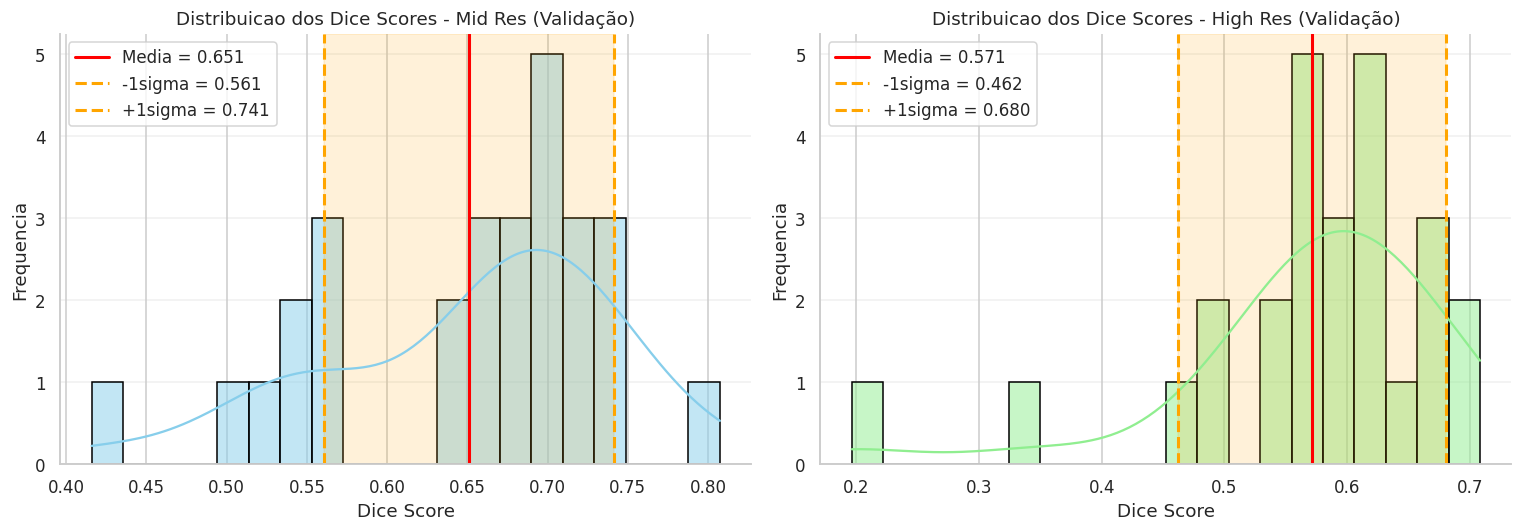

In [21]:
viz.comparison.plot_dice_distribution_by_subset(df_mid_val, df_high_val, "Validação")

### Treino (Train)

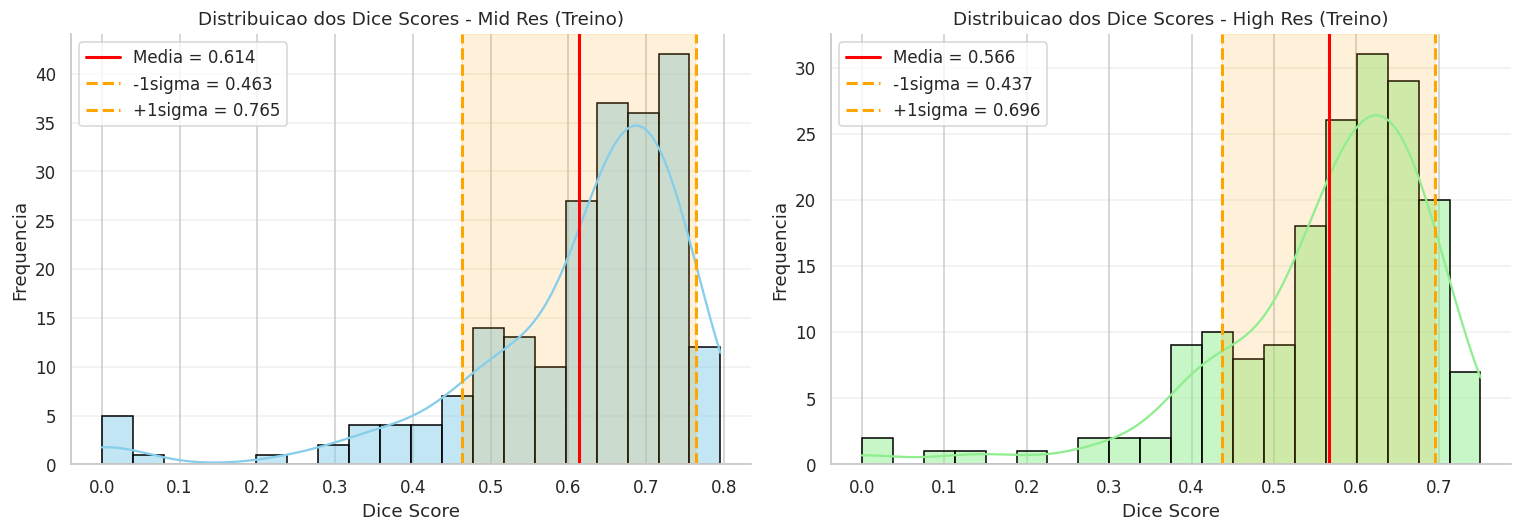

In [22]:
viz.comparison.plot_dice_distribution_by_subset(df_mid_train, df_high_train, "Treino")

### Teste (Test)

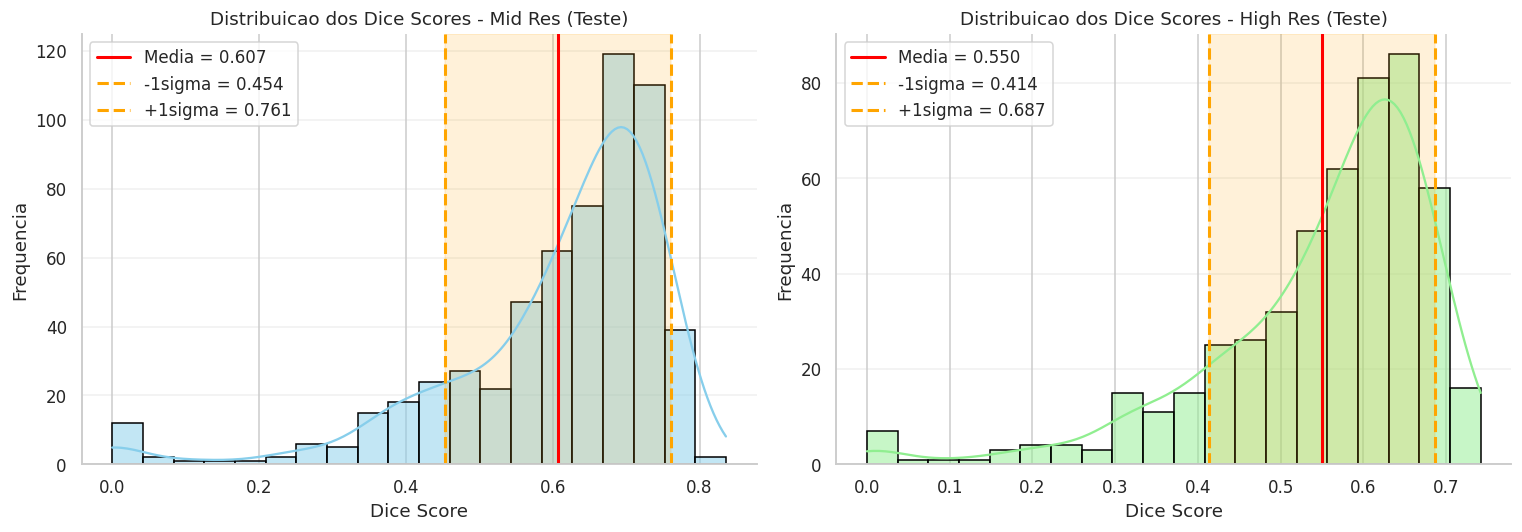

In [23]:
viz.comparison.plot_dice_distribution_by_subset(df_mid_test, df_high_test, "Teste")

## Comparação: Métodos de IA vs Método Matemático

Esta seção compara os Dice Scores dos métodos de IA com o pipeline matemático para **Mid Res** e **High Res**.

- IA: resultados em ../output/ia_results (todos os CSVs disponíveis).
- Matemático: ostios_{train,val,test}_summary.csv de Mid Res e High Res.
- Filtro de comparação: no método matemático, são considerados apenas os IMG_ID que também aparecem nos métodos de IA (por resolução-alvo).
- Comparação agregada por método (média, desvio e quartis).

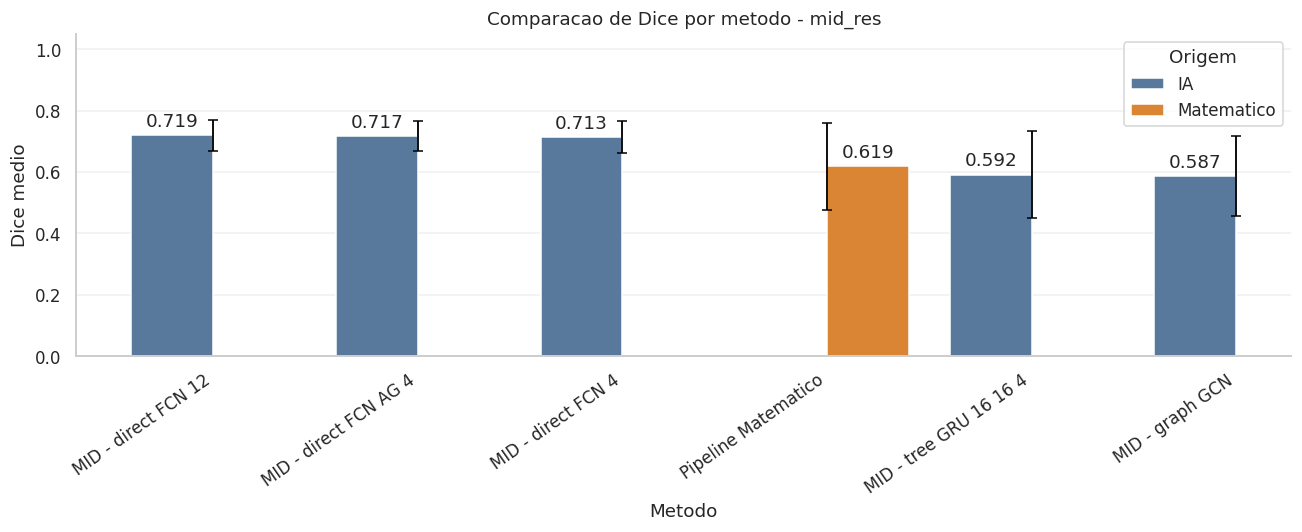

In [24]:
if comparison_agg_df.empty:
    raise ValueError("comparison_agg_df está vazio. Execute a célula de carregamento na seção 'Carregamento de dados'.")

viz.comparison.plot_comparison_bar_by_resolution(comparison_agg_df, "mid_res")

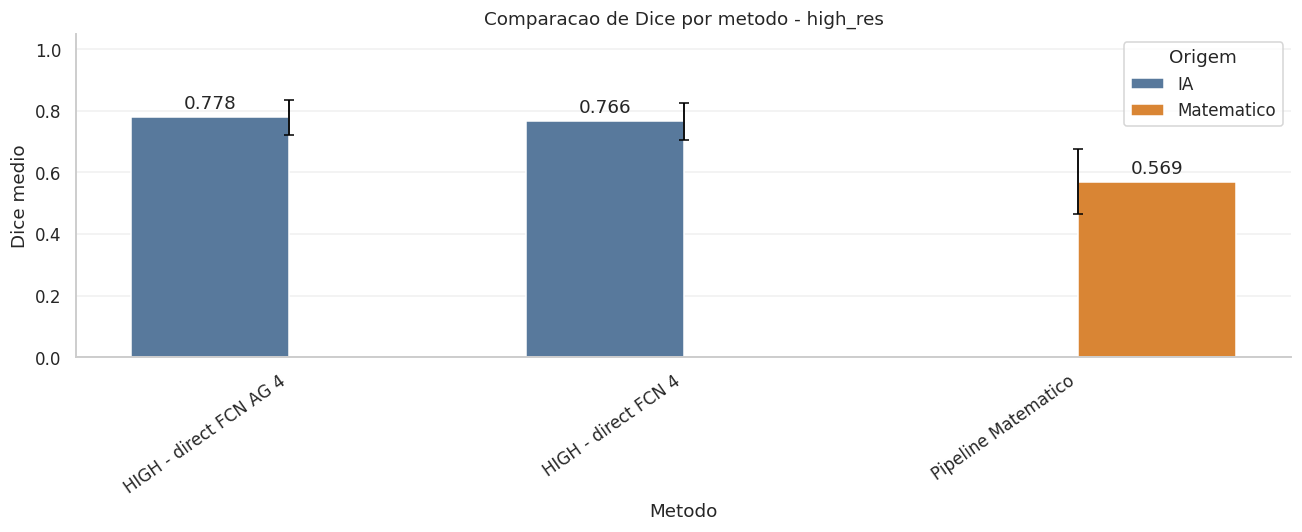

In [25]:
if comparison_agg_df.empty:
    raise ValueError("comparison_agg_df está vazio. Execute a célula de carregamento na seção 'Carregamento de dados'.")

viz.comparison.plot_comparison_bar_by_resolution(comparison_agg_df, "high_res")